# Acoustic Anomaly Detection Using Mel Spectrograms and CNN (MIMII Slider Dataset)

This notebook implements the acoustic modality of a multimodal structural anomaly detection framework using machine sound recordings from the MIMII dataset. The objective is to train a convolutional neural network capable of distinguishing between normal and abnormal acoustic signals produced by industrial machinery. Raw audio waveforms are first transformed into Mel spectrogram representations, which capture the frequency characteristics of the signal over time and allow audio data to be processed using image-based deep learning models. A CNN architecture is then trained on these spectrograms to classify machine states. The resulting model represents the audio branch of a multimodal detection pipeline, complementing the visual crack detection model.

## Environment Setup
This notebook implements the acoustic modality of a multimodal structural anomaly detection framework using machine sound recordings from the MIMII dataset. The objective is to train a convolutional neural network capable of distinguishing between normal and abnormal acoustic signals produced by industrial machinery. Raw audio waveforms are first transformed into Mel spectrogram representations, which capture the frequency characteristics of the signal over time and allow audio data to be processed using image-based deep learning models. A CNN architecture is then trained on these spectrograms to classify machine states. The resulting model represents the audio branch of a multimodal detection pipeline, complementing the visual crack detection model.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import librosa
import librosa.display

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from tqdm import tqdm


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("GPU count:", torch.cuda.device_count())

torch.backends.cudnn.benchmark = True

Device: cuda
GPU count: 2


## Dataset Path and Audio File Collection

This section defines the root directory of the MIMII audio dataset and collects all audio file paths contained within the directory structure. The dataset consists of recordings from multiple machine IDs, each containing two classes: normal and abnormal machine states. By scanning all folders recursively, the notebook identifies every .wav file and stores its path. Labels are inferred automatically from the directory names, where files located inside a normal directory are assigned label 0 and files inside an abnormal directory are assigned label 1. This approach allows the dataset to be constructed without requiring external annotation files.

In [2]:
audio_root = "/kaggle/input/datasets/jeandw/mimii-partial/0_dB_slider/slider"

audio_files = []
labels = []

for root, dirs, files in os.walk(audio_root):
    for file in files:
        if file.endswith(".wav"):
            filepath = os.path.join(root, file)
            audio_files.append(filepath)
            if "abnormal" in filepath:
                labels.append(1)
            else:
                labels.append(0)
print("Total audio samples:", len(audio_files))

Total audio samples: 4094


In [3]:
print("Unique labels:", set(labels))
print("Normal samples:", labels.count(0))
print("Abnormal samples:", labels.count(1))

Unique labels: {0, 1}
Normal samples: 3204
Abnormal samples: 890


## Train / Validation Split

To evaluate the performance of the acoustic classification model, the dataset must be divided into training and validation subsets. The training subset is used to update the model weights during optimization, while the validation subset is used to measure the model’s ability to generalize to unseen audio samples. An 80–20 split is used, meaning that 80% of the audio files are used for training and 20% are reserved for validation. This ensures that evaluation metrics represent the model’s actual predictive capability rather than memorization of training data.

In [4]:
train_files, val_files, train_labels, val_labels = train_test_split(
    audio_files,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

## Convert Audio to Mel Spectrogram

Raw audio recordings represent sound as time-domain waveforms, which are not directly suitable for convolutional neural networks. To extract meaningful frequency patterns from the signal, each audio file is converted into a Mel spectrogram. A spectrogram represents how different frequency components evolve over time, effectively transforming the audio waveform into a two-dimensional representation similar to an image. The Mel scale approximates human auditory perception and highlights perceptually relevant frequency features. The spectrogram is resized to 224×224 dimensions so that it can be processed efficiently by the CNN architecture.

In [5]:
def audio_to_spectrogram(file_path):
    y, sr = librosa.load(file_path, sr=None)
    spec = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_mels=128
    )
    spec = librosa.power_to_db(spec)
    spec = librosa.util.fix_length(spec, size=224, axis=1)
    spec = spec[:224, :224]
    return spec

## Custom Audio Dataset Class

This section defines a custom PyTorch dataset class that loads audio files and converts them into spectrogram tensors during training. Each time a sample is requested, the dataset reads the corresponding audio file, transforms it into a Mel spectrogram, and converts the spectrogram into a tensor representation suitable for neural network input. The spectrogram is expanded with a channel dimension so it can be processed by convolutional layers. The dataset class returns both the spectrogram tensor and its associated label, enabling seamless integration with PyTorch DataLoaders for efficient batch processing.

In [6]:
class AudioDataset(Dataset):
    def __init__(self, files, labels):
        self.files = files
        self.labels = labels

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        spec = audio_to_spectrogram(self.files[idx])
        spec = torch.tensor(spec).unsqueeze(0).float()
        label = torch.tensor(self.labels[idx]).long()
        return spec, label

## Creating Dataloader

DataLoaders are used to efficiently supply batches of spectrogram data to the neural network during training and evaluation. Instead of loading the entire dataset into memory, DataLoaders fetch data in smaller batches that can be processed by the GPU. The training DataLoader shuffles the dataset to prevent the model from learning patterns related to the order of the data. The validation DataLoader keeps the order fixed to ensure consistent evaluation. Batch processing significantly improves computational efficiency during model training.

In [7]:
train_dataset = AudioDataset(train_files, train_labels)
val_dataset = AudioDataset(val_files, val_labels)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

## CNN Model for Spectrogram Classification

To classify acoustic signals, a convolutional neural network is used to analyze spectrogram representations of the audio data. Since spectrograms resemble images, CNN architectures can effectively learn spatial patterns corresponding to frequency-time structures. The model defined here contains multiple convolutional layers followed by pooling layers that progressively reduce spatial resolution while extracting hierarchical features. These features capture important acoustic characteristics such as harmonic structures and transient anomalies. The extracted features are flattened and passed through fully connected layers that produce the final classification output.

In [8]:
class AudioCNN(nn.Module):
    def __init__(self):
        super(AudioCNN, self).__init__()
        self.conv1 = nn.Conv2d(1,16,3,padding=1)
        self.conv2 = nn.Conv2d(16,32,3,padding=1)
        self.pool = nn.MaxPool2d(2,2)
        self.adapt = nn.AdaptiveAvgPool2d((8,8))
        self.fc1 = nn.Linear(32*8*8,128)
        self.fc2 = nn.Linear(128,2)

    def forward(self,x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.adapt(x)
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

## Model Initialization and Training Configuration

This section initializes the acoustic classification model and configures the training parameters. The CNN model is transferred to the GPU device to accelerate training using CUDA. The CrossEntropyLoss function is used because the task involves binary classification between normal and abnormal machine states. The Adam optimizer is selected for its adaptive learning rate capabilities and stable convergence properties. These components define the learning framework for the audio model, allowing it to update its parameters during training based on the spectrogram data.

In [9]:
audio_model = AudioCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(audio_model.parameters(), lr=0.0001)

## Training Loop

This section implements the training process for the acoustic CNN model. During each epoch, the model processes batches of spectrogram data from the training dataset, computes predictions, and calculates the classification loss. Gradients are then computed using backpropagation, and the optimizer updates the model parameters to minimize the loss. The training loss is accumulated across batches and averaged at the end of each epoch. This iterative process allows the model to progressively learn acoustic patterns that distinguish normal machine operation from abnormal behavior.

In [10]:
epochs = 10
train_losses = []

for epoch in range(epochs):
    audio_model.train()
    running_loss = 0
    for specs, labels in tqdm(train_loader):
        specs = specs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = audio_model(specs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)
    print(f"Epoch {epoch+1}/{epochs} - Loss: {epoch_loss:.4f}")

100%|██████████| 52/52 [02:50<00:00,  3.28s/it]


Epoch 1/10 - Loss: 0.4968


100%|██████████| 52/52 [02:08<00:00,  2.48s/it]


Epoch 2/10 - Loss: 0.4114


100%|██████████| 52/52 [02:08<00:00,  2.47s/it]


...

Epoch 8/10 - Loss: 0.2709


100%|██████████| 52/52 [02:11<00:00,  2.53s/it]


Epoch 9/10 - Loss: 0.2642


100%|██████████| 52/52 [02:08<00:00,  2.47s/it]

Epoch 10/10 - Loss: 0.2559


## Model Evaluation

After training the acoustic CNN model, it is evaluated on the validation dataset to assess its generalization performance. During evaluation, gradient computation is disabled to reduce memory usage and improve efficiency. The model processes each batch of validation spectrograms and produces predicted class labels. These predictions are collected alongside the ground truth labels so that classification metrics can be computed. This evaluation step provides an objective measure of how accurately the model can detect abnormal acoustic patterns in unseen audio recordings.

In [11]:
audio_model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for specs, labels in val_loader:
        specs = specs.to(device)
        outputs = audio_model(specs)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

## Evaluation Metrics and Confusion Matrix

To assess the effectiveness of the acoustic anomaly detection model, several evaluation metrics are computed using the predictions obtained from the validation dataset. These metrics include precision, recall, and F1 score, which provide insights into the model’s ability to correctly identify abnormal acoustic patterns. A confusion matrix is also generated to visualize the number of correct and incorrect predictions for each class. This visualization helps identify potential misclassification patterns and provides a clear overview of the model’s performance.

              precision    recall  f1-score   support

           0       0.94      1.00      0.97       641
           1       0.99      0.77      0.86       178

    accuracy                           0.95       819
   macro avg       0.96      0.88      0.92       819
weighted avg       0.95      0.95      0.95       819



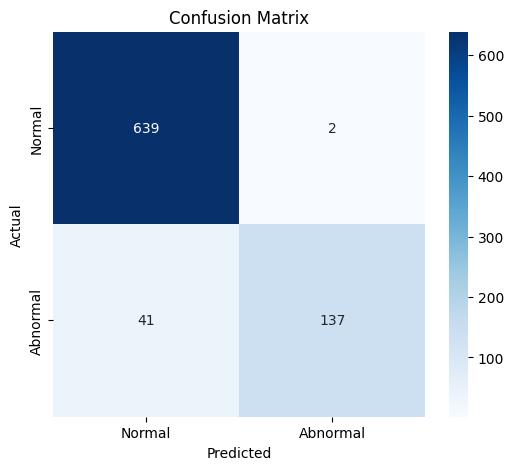

In [12]:
print(classification_report(all_labels, all_preds))
cm = confusion_matrix(all_labels, all_preds, labels=[0,1])
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal","Abnormal"],
    yticklabels=["Normal","Abnormal"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()